In [ ]:
import numpy as np
from SALib.sample import sobol as sobol_sample
from SALib.analyze import sobol
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import json
import pandas as pd
import csv
from copy import deepcopy
import scienceplots
plt.style.use(['science','ieee'])
# plt.rcParams['axes.spines.top'] = False
# plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.top'] = False
plt.rcParams['ytick.right'] = False
plt.rcParams.update({
    "font.family": "serif",   
    "font.serif": ["Times"],  
    "font.size": 8,
    "lines.linewidth": 0.8,     
    "lines.markersize": 3,        
    "axes.linewidth": 0.5,        
    "xtick.major.width": 0.5,     
    "ytick.major.width": 0.5})          
plt.rcParams['patch.linewidth'] = 0.5
import matplotlib as mpl


/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore


# No AS generate input

In [ ]:

# define bounds

# names1
# Emax_ra_bounds = [0.17, 0.5]
# Emin_ra_bounds = [0.01, 0.16]
# m1_ra_bounds = [1.0, 10]
# m2_ra_bounds = [5, 20]
# V0ra_bounds = [-50, 30]
# Emax_rv_bounds = [0.3, 1.2] 
# Emin_rv_bounds = [0.01, 0.25]
# m1_rv_bounds = [1.0, 10]
# m2_rv_bounds = [10, 50]
# V0rv_bounds = [-50, 80]
Emax_la_bounds = [0.14, 0.5]
Emin_la_bounds = [0.05, 0.13]
# m1_la_bounds = [1.0, 10]
# m2_la_bounds = [5, 20]
# V0la_bounds = [-50, 70]
Emax_lv_bounds = [1, 4]
Emin_lv_bounds = [0.01, 0.8]
m1_lv_bounds = [1.0, 10]
# m2_lv_bounds = [10, 50]
V0lv_bounds = [-50, 50]
bounds = [Emax_la_bounds, Emin_la_bounds, Emax_lv_bounds, Emin_lv_bounds, m1_lv_bounds, V0lv_bounds]

# names2
# Amax_tv_bounds = [4.0, 5.0]
# Amin_tv_bounds = [1e-06, 1e-05]
# Kvo_tv_bounds = [0.003, 0.3]
# Kvc_tv_bounds = [0.004, 0.4]
# Amax_pv_bounds = [4.0, 5.0]
# Amin_pv_bounds = [1e-06, 1e-05]
# Kvo_pv_bounds = [0.002, 0.2]
# Kvc_pv_bounds = [0.002, 0.2]
# Amax_mv_bounds = [4.0, 5.0]
# Amin_mv_bounds = [1e-06, 1e-05]
# Kvo_mv_bounds = [0.003, 0.3]
# Kvc_mv_bounds = [0.004, 0.4]
Amax_av_bounds = [3.0, 4.0]
# Amin_av_bounds = [1e-06, 1e-05]
# Kvo_av_bounds = [0.0012, 0.12]
Kvc_av_bounds = [0.0012, 0.12]
bounds += [
    Amax_av_bounds, Kvc_av_bounds
]

# names3
HR_bounds = [40, 180]
# density_bounds = [0.9, 1.3]
# Rao_bounds = [0.01, 0.1]
Ca_syst_bounds = [0.5, 5]
Ra_syst_bounds = [0.1, 3]
Cv_syst_bounds = [10, 150]
Rv_syst_bounds = [0.01, 0.2]
# Rpa_bounds = [0.001, 0.1]
# Ca_pulm_bounds = [1, 10]
# Ra_pulm_bounds = [0.01, 1]
# Cv_pulm_bounds = [5, 50]
# Rv_pulm_bounds = [0.0005, 0.05]
bounds += [
    HR_bounds, Ca_syst_bounds, Ra_syst_bounds, Cv_syst_bounds, Rv_syst_bounds
]

# names4
# Ra_LAD_bounds = [0.1, 10]
# Ra_LCX_bounds = [0.1, 10]
# Ra_RCA_bounds = [0.1, 10]
Rmicro_max_LAD_bounds = [43, 170]
#Rmicro_min_LAD_bounds = [25, 42]
Rmicro_max_LCX_bounds = [52, 170]
#Rmicro_min_LCX_bounds = [22, 51]
Rmicro_max_RCA_bounds = [59, 170]
#Rmicro_min_RCA_bounds = [28, 58]
# Rv_LAD_bounds = [0.1, 10]
# Rv_LCX_bounds = [0.1, 10]
# Rv_RCA_bounds = [0.1, 10]
# Ca_LAD_bounds = [0.001, 0.2]
# Ca_LCX_bounds = [0.001, 0.2]
# Ca_RCA_bounds = [0.001, 0.2]
Cmicro_LAD_bounds = [0.05, 2]
Cmicro_LCX_bounds = [0.05, 2]
Cmicro_RCA_bounds = [0.05, 2]
hypertrophy_factor_bounds = [1.0, 3.0]
bounds += [
    Rmicro_max_LAD_bounds, Rmicro_max_LCX_bounds, Rmicro_max_RCA_bounds,
    Cmicro_LAD_bounds, Cmicro_LCX_bounds, Cmicro_RCA_bounds, hypertrophy_factor_bounds
]

# names5
# icVra_bounds = [10, 100]
# icVrv_bounds = [85, 250]
# icVla_bounds = [10, 100]
icVlv_bounds = [75, 250]
# icQtv_bounds = [0, 1]
# icQpv_bounds = [0, 1]
# icQmv_bounds = [0, 1]
# icQav_bounds = [0, 1]
# iceps_tv_bounds = [0, 1]
# iceps_pv_bounds = [0, 1]
# iceps_mv_bounds = [0, 1]
# iceps_av_bounds = [0, 1]
icPa_syst_bounds = [30, 140]
icPv_syst_bounds = [2, 50]
# icPa_pulm_bounds = [5, 20]
# icPv_pulm_bounds = [1, 14]
# icPa_LAD_bounds = [40, 60]
# icPv_LAD_bounds = [10, 18]
# icPa_LCX_bounds = [40, 60]
# icPv_LCX_bounds = [10, 18]
# icPa_RCA_bounds = [40, 60]
# icPv_RCA_bounds = [10, 18]
bounds += [
    icVlv_bounds, icPa_syst_bounds, icPv_syst_bounds
]

# define names
names1 = ['Emax_la', 'Emin_la', 'Emax_lv', 'Emin_lv', 'm1_lv', 'V0lv']
names2 = ['Amax_av', 'Kvc_av']
names3 = ['HR', 'Ca_syst', 'Ra_syst', 'Cv_syst', 'Rv_syst']
names4 = ['Rmicro_max_LAD', 'Rmicro_max_LCX', 'Rmicro_max_RCA', 'Cmicro_LAD', 'Cmicro_LCX', 'Cmicro_RCA', 'hypertrophy_factor']
names5 = ['icVlv', 'icPa_syst', 'icPv_syst']
names = names1 + names2 + names3 + names4 + names5
print(names)
parameters_count = len(names)
print(f"params count: {parameters_count}")



print(bounds)
print(f"Bounds len: {len(bounds)}, expected len: {parameters_count}")




['Emax_la', 'Emin_la', 'Emax_lv', 'Emin_lv', 'm1_lv', 'V0lv', 'Amax_av', 'Kvc_av', 'HR', 'Ca_syst', 'Ra_syst', 'Cv_syst', 'Rv_syst', 'Rmicro_max_LAD', 'Rmicro_max_LCX', 'Rmicro_max_RCA', 'Cmicro_LAD', 'Cmicro_LCX', 'Cmicro_RCA', 'hypertrophy_factor', 'icVlv', 'icPa_syst', 'icPv_syst']
params count: 23
[[0.14, 0.5], [0.05, 0.13], [1, 4], [0.01, 0.8], [1.0, 10], [-50, 50], [3.0, 4.0], [0.0012, 0.12], [40, 180], [0.5, 5], [0.1, 3], [10, 150], [0.01, 0.2], [43, 170], [52, 170], [59, 170], [0.05, 2], [0.05, 2], [0.05, 2], [1.0, 3.0], [75, 250], [30, 140], [2, 50]]
Bounds len: 23, expected len: 23


In [ ]:
problem = {
    'num_vars': parameters_count,
    'names': names,
    'bounds': bounds
}

N_samples = 3000

param_values = sobol_sample.sample(problem, N_samples, calc_second_order=True, scramble=True)

print(f"Generated {param_values.shape[0]} parameter sets for model evaluation.")

input_data = {}
for i in range(len(names)):
    input_data[names[i]] = param_values[:,i]

df = pd.DataFrame(input_data)
df.to_csv("Data/sobol_input_data_selparams23_noAS.csv", index=False)

# No AS Analyse results

In [3]:
output_sobol_df_noAS = pd.read_csv("Data/sobol_output_data_noAS.csv")
input_sobol_df_noAS = pd.read_csv("Data/sobol_input_data_selparams23_noAS.csv")

output_sobol_df_noAS.describe()

,stability_reached,stability_reached_cycle,Pao_max,Pao_min,Pao_mean,Ppt_max,Ppt_min,Ppt_mean,Pa_syst_max,Pa_syst_min,...,CO_lv,RVET,LVET,Ees_rv,Ees_lv,Ea_rv,Ea_lv,VAC_rv,VAC_lv,DeltaE
count,210000.0,210000.000000,210000.000000,210000.000000,210000.000000,210000.000000,210000.000000,210000.000000,210000.000000,210000.000000,...,210000.000000,210000.000000,210000.000000,210000.000000,210000.000000,210000.000000,210000.000000,210000.000000,210000.000000,210000.000000
mean,1.0,70.067138,175.135914,140.769725,155.707814,51.531936,33.181360,40.261856,161.920451,140.627350,...,6308.332253,0.206993,0.270046,0.504023,2.357617,0.703469,2.925304,1.418928,1.464828,2.233142
std,0.0,37.724072,111.350885,98.683149,103.630664,25.148399,19.507140,21.339303,106.875869,98.676198,...,3678.265207,0.109698,0.254551,0.061929,0.878792,0.370721,1.740510,0.778178,1.163475,6.482887
min,1.0,13.000000,16.051999,4.597067,8.784790,8.342276,1.845591,4.272161,10.175565,4.523659,...,489.442769,0.060953,0.064363,0.178352,0.384066,0.046273,0.073778,0.211199,0.030823,-97.098779
25%,1.0,42.000000,94.188900,68.250142,80.380010,32.378531,18.827413,24.256984,84.261758,68.138589,...,3584.608142,0.128508,0.124727,0.461854,1.596888,0.441180,1.525944,0.883329,0.642300,-0.056514
50%,1.0,61.000000,147.358472,116.248844,129.527284,46.139335,28.451021,35.490355,134.894068,116.187345,...,5511.765711,0.172568,0.176281,0.520321,2.336213,0.620776,2.620505,1.243707,1.144839,2.009279
75%,1.0,88.000000,226.940277,187.712756,204.621195,65.600316,43.026782,51.683201,211.564696,187.594183,...,8168.576057,0.258396,0.303074,0.554883,3.108956,0.874982,4.086889,1.766252,1.932998,4.823454
max,1.0,360.000000,1120.900247,1015.026950,1047.915865,177.965027,149.194742,158.322111,1051.748624,1014.979005,...,32729.669113,1.485359,1.499476,0.590525,7.470306,4.374693,9.149209,8.753582,9.558119,76.614846


In [ ]:
problem = {
    'num_vars': parameters_count,
    'names': names,
    'bounds': bounds
}
master_s1_st = []
master_s2 = []

target_outputs = ["Ein", "VO2_total", "CO_lv", "Pa_syst_mean", "DeltaE"]
for target in target_outputs:
    print(f"Analyzing {target}...")
    Y = output_sobol_df_noAS[target].values
    
    Si = sobol.analyze(problem, Y, calc_second_order=True, print_to_console=False, num_resamples=5000, parallel=True, n_processors=10)
    
    df_1d = pd.DataFrame({
        'Target_Output': target,
        'Parameter': problem['names'],
        'S1': Si['S1'],
        'S1_conf': Si['S1_conf'],
        'ST': Si['ST'],
        'ST_conf': Si['ST_conf']
    })
    master_s1_st.append(df_1d)
    

    s2_data = []
    num_vars = problem['num_vars']
    
    for i in range(num_vars):
        for j in range(i + 1, num_vars):  
            s2_data.append({
                'Target_Output': target,
                'Param_1': problem['names'][i],
                'Param_2': problem['names'][j],
                'S2': Si['S2'][i][j],
                'S2_conf': Si['S2_conf'][i][j]
            })
            
    df_2d = pd.DataFrame(s2_data)
    master_s2.append(df_2d)


final_s1_st_df = pd.concat(master_s1_st, ignore_index=True)
final_s2_df = pd.concat(master_s2, ignore_index=True)

final_s1_st_df.to_csv('res/Sobol_S1_ST_All_Targets_noAS.csv', index=False)

significant_s2_df = final_s2_df[final_s2_df['S2'] > 0.01].sort_values(by=['Target_Output', 'S2'], ascending=[True, False])
significant_s2_df.to_csv('res/Sobol_S2_Interactions_noAS.csv', index=False)

print("\nAnalysis complete!")
print("Saved 1st/Total order results to: res/Sobol_S1_ST_All_Targets_noAS.csv")
print("Saved significant 2nd order interactions to: res/Sobol_S2_Interactions_noAS.csv")

Analyzing Ein...


/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore
/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore
/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore
/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore
/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is re

Analyzing VO2_total...


/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore
/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore
/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore
/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore
/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is re

Analyzing CO_lv...


...

Analyzing Pa_syst_mean...


/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore
/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore
/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore
/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore
/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is re

Analyzing DeltaE...


/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore
/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore
/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore
/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore
/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is re


Analysis complete!
Saved 1st/Total order results to: res/Sobol_S1_ST_All_Targets_noAS.csv
Saved significant 2nd order interactions to: res/Sobol_S2_Interactions_noAS.csv


# AS generate input

In [ ]:

# define bounds

# names1
# Emax_ra_bounds = [0.17, 0.5]
# Emin_ra_bounds = [0.01, 0.16]
# m1_ra_bounds = [1.0, 10]
# m2_ra_bounds = [5, 20]
# V0ra_bounds = [-50, 30]
# Emax_rv_bounds = [0.3, 1.2] 
# Emin_rv_bounds = [0.01, 0.25]
# m1_rv_bounds = [1.0, 10]
# m2_rv_bounds = [10, 50]
# V0rv_bounds = [-50, 80]
Emax_la_bounds = [0.14, 0.5]
Emin_la_bounds = [0.05, 0.13]
# m1_la_bounds = [1.0, 10]
# m2_la_bounds = [5, 20]
# V0la_bounds = [-50, 70]
Emax_lv_bounds = [1, 4]
Emin_lv_bounds = [0.1, 0.8]
m1_lv_bounds = [1.0, 10]
# m2_lv_bounds = [10, 50]
V0lv_bounds = [-50, 50]
bounds = [Emax_la_bounds, Emin_la_bounds, Emax_lv_bounds, Emin_lv_bounds, m1_lv_bounds, V0lv_bounds]

# names2
# Amax_tv_bounds = [4.0, 5.0]
# Amin_tv_bounds = [1e-06, 1e-05]
# Kvo_tv_bounds = [0.003, 0.3]
# Kvc_tv_bounds = [0.004, 0.4]
# Amax_pv_bounds = [4.0, 5.0]
# Amin_pv_bounds = [1e-06, 1e-05]
# Kvo_pv_bounds = [0.002, 0.2]
# Kvc_pv_bounds = [0.002, 0.2]
# Amax_mv_bounds = [4.0, 5.0]
# Amin_mv_bounds = [1e-06, 1e-05]
# Kvo_mv_bounds = [0.003, 0.3]
# Kvc_mv_bounds = [0.004, 0.4]
Amax_av_bounds = [0.2, 1.0]
# Amin_av_bounds = [1e-06, 1e-05]
# Kvo_av_bounds = [0.0012, 0.12]
Kvc_av_bounds = [0.00012, 0.12]
bounds += [
    Amax_av_bounds, Kvc_av_bounds
]

# names3
HR_bounds = [40, 180]
# density_bounds = [0.9, 1.3]
# Rao_bounds = [0.01, 0.1]
Ca_syst_bounds = [0.5, 5]
Ra_syst_bounds = [0.1, 3]
Cv_syst_bounds = [10, 150]
Rv_syst_bounds = [0.01, 0.2]
# Rpa_bounds = [0.001, 0.1]
# Ca_pulm_bounds = [1, 10]
# Ra_pulm_bounds = [0.01, 1]
# Cv_pulm_bounds = [5, 50]
# Rv_pulm_bounds = [0.0005, 0.05]
bounds += [
    HR_bounds, Ca_syst_bounds, Ra_syst_bounds, Cv_syst_bounds, Rv_syst_bounds
]

# names4
# Ra_LAD_bounds = [0.1, 10]
# Ra_LCX_bounds = [0.1, 10]
# Ra_RCA_bounds = [0.1, 10]
Rmicro_max_LAD_bounds = [43, 170]
#Rmicro_min_LAD_bounds = [25, 42]
Rmicro_max_LCX_bounds = [52, 170]
#Rmicro_min_LCX_bounds = [22, 51]
Rmicro_max_RCA_bounds = [59, 170]
#Rmicro_min_RCA_bounds = [28, 58]
# Rv_LAD_bounds = [0.1, 10]
# Rv_LCX_bounds = [0.1, 10]
# Rv_RCA_bounds = [0.1, 10]
# Ca_LAD_bounds = [0.001, 0.2]
# Ca_LCX_bounds = [0.001, 0.2]
# Ca_RCA_bounds = [0.001, 0.2]
Cmicro_LAD_bounds = [0.05, 2]
Cmicro_LCX_bounds = [0.05, 2]
Cmicro_RCA_bounds = [0.05, 2]
hypertrophy_factor_bounds = [1.0, 3.0]
bounds += [
    Rmicro_max_LAD_bounds, Rmicro_max_LCX_bounds, Rmicro_max_RCA_bounds,
    Cmicro_LAD_bounds, Cmicro_LCX_bounds, Cmicro_RCA_bounds, hypertrophy_factor_bounds
]

# names5
# icVra_bounds = [10, 100]
# icVrv_bounds = [85, 250]
# icVla_bounds = [10, 100]
icVlv_bounds = [75, 180]
# icQtv_bounds = [0, 1]
# icQpv_bounds = [0, 1]
# icQmv_bounds = [0, 1]
# icQav_bounds = [0, 1]
# iceps_tv_bounds = [0, 1]
# iceps_pv_bounds = [0, 1]
# iceps_mv_bounds = [0, 1]
# iceps_av_bounds = [0, 1]
icPa_syst_bounds = [30, 140]
icPv_syst_bounds = [2, 50]
# icPa_pulm_bounds = [5, 20]
# icPv_pulm_bounds = [1, 14]
# icPa_LAD_bounds = [40, 60]
# icPv_LAD_bounds = [10, 18]
# icPa_LCX_bounds = [40, 60]
# icPv_LCX_bounds = [10, 18]
# icPa_RCA_bounds = [40, 60]
# icPv_RCA_bounds = [10, 18]
bounds += [
    icVlv_bounds, icPa_syst_bounds, icPv_syst_bounds
]

# define names
names1 = ['Emax_la', 'Emin_la', 'Emax_lv', 'Emin_lv', 'm1_lv', 'V0lv']
names2 = ['Amax_av', 'Kvc_av']
names3 = ['HR', 'Ca_syst', 'Ra_syst', 'Cv_syst', 'Rv_syst']
names4 = ['Rmicro_max_LAD', 'Rmicro_max_LCX', 'Rmicro_max_RCA', 'Cmicro_LAD', 'Cmicro_LCX', 'Cmicro_RCA', 'hypertrophy_factor']
names5 = ['icVlv', 'icPa_syst', 'icPv_syst']
names = names1 + names2 + names3 + names4 + names5
print(names)
parameters_count = len(names)
print(f"params count: {parameters_count}")



print(bounds)
print(f"Bounds len: {len(bounds)}, expected len: {parameters_count}")




['Emax_la', 'Emin_la', 'Emax_lv', 'Emin_lv', 'm1_lv', 'V0lv', 'Amax_av', 'Kvc_av', 'HR', 'Ca_syst', 'Ra_syst', 'Cv_syst', 'Rv_syst', 'Rmicro_max_LAD', 'Rmicro_max_LCX', 'Rmicro_max_RCA', 'Cmicro_LAD', 'Cmicro_LCX', 'Cmicro_RCA', 'hypertrophy_factor', 'icVlv', 'icPa_syst', 'icPv_syst']
params count: 23
[[0.14, 0.5], [0.05, 0.13], [1, 4], [0.1, 0.8], [1.0, 10], [-50, 50], [0.2, 1.0], [0.00012, 0.12], [40, 180], [0.5, 5], [0.1, 3], [10, 150], [0.01, 0.2], [43, 170], [52, 170], [59, 170], [0.05, 2], [0.05, 2], [0.05, 2], [1.0, 3.0], [75, 180], [30, 140], [2, 50]]
Bounds len: 23, expected len: 23


In [ ]:
problem = {
    'num_vars': parameters_count,
    'names': names,
    'bounds': bounds
}

N_samples = 5000

param_values = sobol_sample.sample(problem, N_samples, calc_second_order=True, scramble=True)

print(f"Generated {param_values.shape[0]} parameter sets for model evaluation.")

input_data = {}
for i in range(len(names)):
    input_data[names[i]] = param_values[:,i]

df = pd.DataFrame(input_data)
df.to_csv("Data/sobol_input_data_selparams23_AS.csv", index=False)

# AS Analyse results

In [6]:
output_sobol_df_AS = pd.read_csv("Data/sobol_output_data_AS.csv")
input_sobol_df_AS = pd.read_csv("Data/sobol_input_data_selparams23_AS.csv")

output_sobol_df_AS.describe()

,stability_reached,stability_reached_cycle,Pao_max,Pao_min,Pao_mean,Ppt_max,Ppt_min,Ppt_mean,Pa_syst_max,Pa_syst_min,...,CO_lv,RVET,LVET,Ees_rv,Ees_lv,Ea_rv,Ea_lv,VAC_rv,VAC_lv,DeltaE
count,210000.0,210000.000000,210000.000000,210000.000000,210000.000000,210000.000000,210000.000000,210000.000000,210000.000000,210000.000000,...,210000.000000,210000.000000,210000.000000,210000.000000,210000.000000,210000.000000,210000.000000,210000.000000,210000.000000,210000.000000
mean,1.0,82.628357,141.114289,117.942942,128.307711,54.674585,38.311924,44.292892,132.966784,117.630976,...,5156.558573,0.191476,0.333154,0.510219,1.520231,0.905777,2.729633,1.821954,2.374005,0.662334
std,0.0,45.269458,85.902220,77.225579,80.551949,27.227529,22.149003,23.758220,82.964658,77.362779,...,2725.717047,0.097785,0.263514,0.057095,0.809840,0.455033,1.560193,0.997543,1.954653,7.155696
min,1.0,15.000000,12.652194,6.322165,10.477216,9.919294,2.835781,5.853340,10.642472,5.909382,...,447.384652,0.055033,0.084594,0.316622,0.117269,0.178075,0.132750,0.317597,0.043077,-105.962852
25%,1.0,49.000000,77.973776,60.776501,68.783606,33.439518,21.492630,25.986554,71.821171,60.388017,...,3121.667939,0.116977,0.164479,0.469225,0.907868,0.585381,1.486839,1.130241,0.999902,-1.159810
50%,1.0,72.000000,120.415614,99.511845,109.004345,48.624500,32.929277,38.698354,113.183987,99.285133,...,4611.050119,0.158996,0.235469,0.525671,1.332741,0.800356,2.443080,1.585406,1.834220,1.163715
75%,1.0,105.000000,183.710325,156.680856,168.339951,70.572592,49.999930,57.574220,174.314923,156.481326,...,6623.366768,0.241883,0.396761,0.558558,1.994602,1.114739,3.753036,2.248510,3.156045,3.688294
max,1.0,416.000000,804.416514,718.426792,753.469326,180.831268,160.275882,164.583649,768.070408,718.468589,...,27820.912519,0.580219,1.499411,0.590527,8.375766,5.164908,8.849450,11.776290,23.503361,46.068876


In [ ]:
problem = {
    'num_vars': parameters_count,
    'names': names,
    'bounds': bounds
}
master_s1_st = []
master_s2 = []

target_outputs = ["Ein", "VO2_total", "CO_lv", "Pa_syst_mean", "DeltaE"]
for target in target_outputs:
    print(f"Analyzing {target}...")
    Y = output_sobol_df_AS[target].values
    
    Si = sobol.analyze(problem, Y, calc_second_order=True, print_to_console=False, num_resamples=5000, parallel=True, n_processors=10)
    
    df_1d = pd.DataFrame({
        'Target_Output': target,
        'Parameter': problem['names'],
        'S1': Si['S1'],
        'S1_conf': Si['S1_conf'],
        'ST': Si['ST'],
        'ST_conf': Si['ST_conf']
    })
    master_s1_st.append(df_1d)
    
    s2_data = []
    num_vars = problem['num_vars']
    
    for i in range(num_vars):
        for j in range(i + 1, num_vars):  
            s2_data.append({
                'Target_Output': target,
                'Param_1': problem['names'][i],
                'Param_2': problem['names'][j],
                'S2': Si['S2'][i][j],
                'S2_conf': Si['S2_conf'][i][j]
            })
            
    df_2d = pd.DataFrame(s2_data)
    master_s2.append(df_2d)


final_s1_st_df = pd.concat(master_s1_st, ignore_index=True)
final_s2_df = pd.concat(master_s2, ignore_index=True)

final_s1_st_df.to_csv('res/Sobol_S1_ST_All_Targets_AS.csv', index=False)


significant_s2_df = final_s2_df[final_s2_df['S2'] > 0.01].sort_values(by=['Target_Output', 'S2'], ascending=[True, False])
significant_s2_df.to_csv('res/Sobol_S2_Interactions_AS.csv', index=False)

print("\nAnalysis complete!")
print("Saved 1st/Total order results to: res/Sobol_S1_ST_All_Targets_AS.csv")
print("Saved significant 2nd order interactions to: res/Sobol_S2_Interactions_AS.csv")

Analyzing Ein...


/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore
/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore
/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore
/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore
/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is re

Analyzing VO2_total...


/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore
/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore
/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore
/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore
/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is re

Analyzing CO_lv...


...

Analyzing Pa_syst_mean...


/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore
/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore
/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore
/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore
/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is re

Analyzing DeltaE...


/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore
/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore
/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore
/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.3)
  import scipy as sp  # type: ignore
/opt/anaconda3/lib/python3.12/site-packages/SALib/util/__init__.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is re


Analysis complete!
Saved 1st/Total order results to: res/Sobol_S1_ST_All_Targets_AS.csv
Saved significant 2nd order interactions to: res/Sobol_S2_Interactions_AS.csv


# Plot

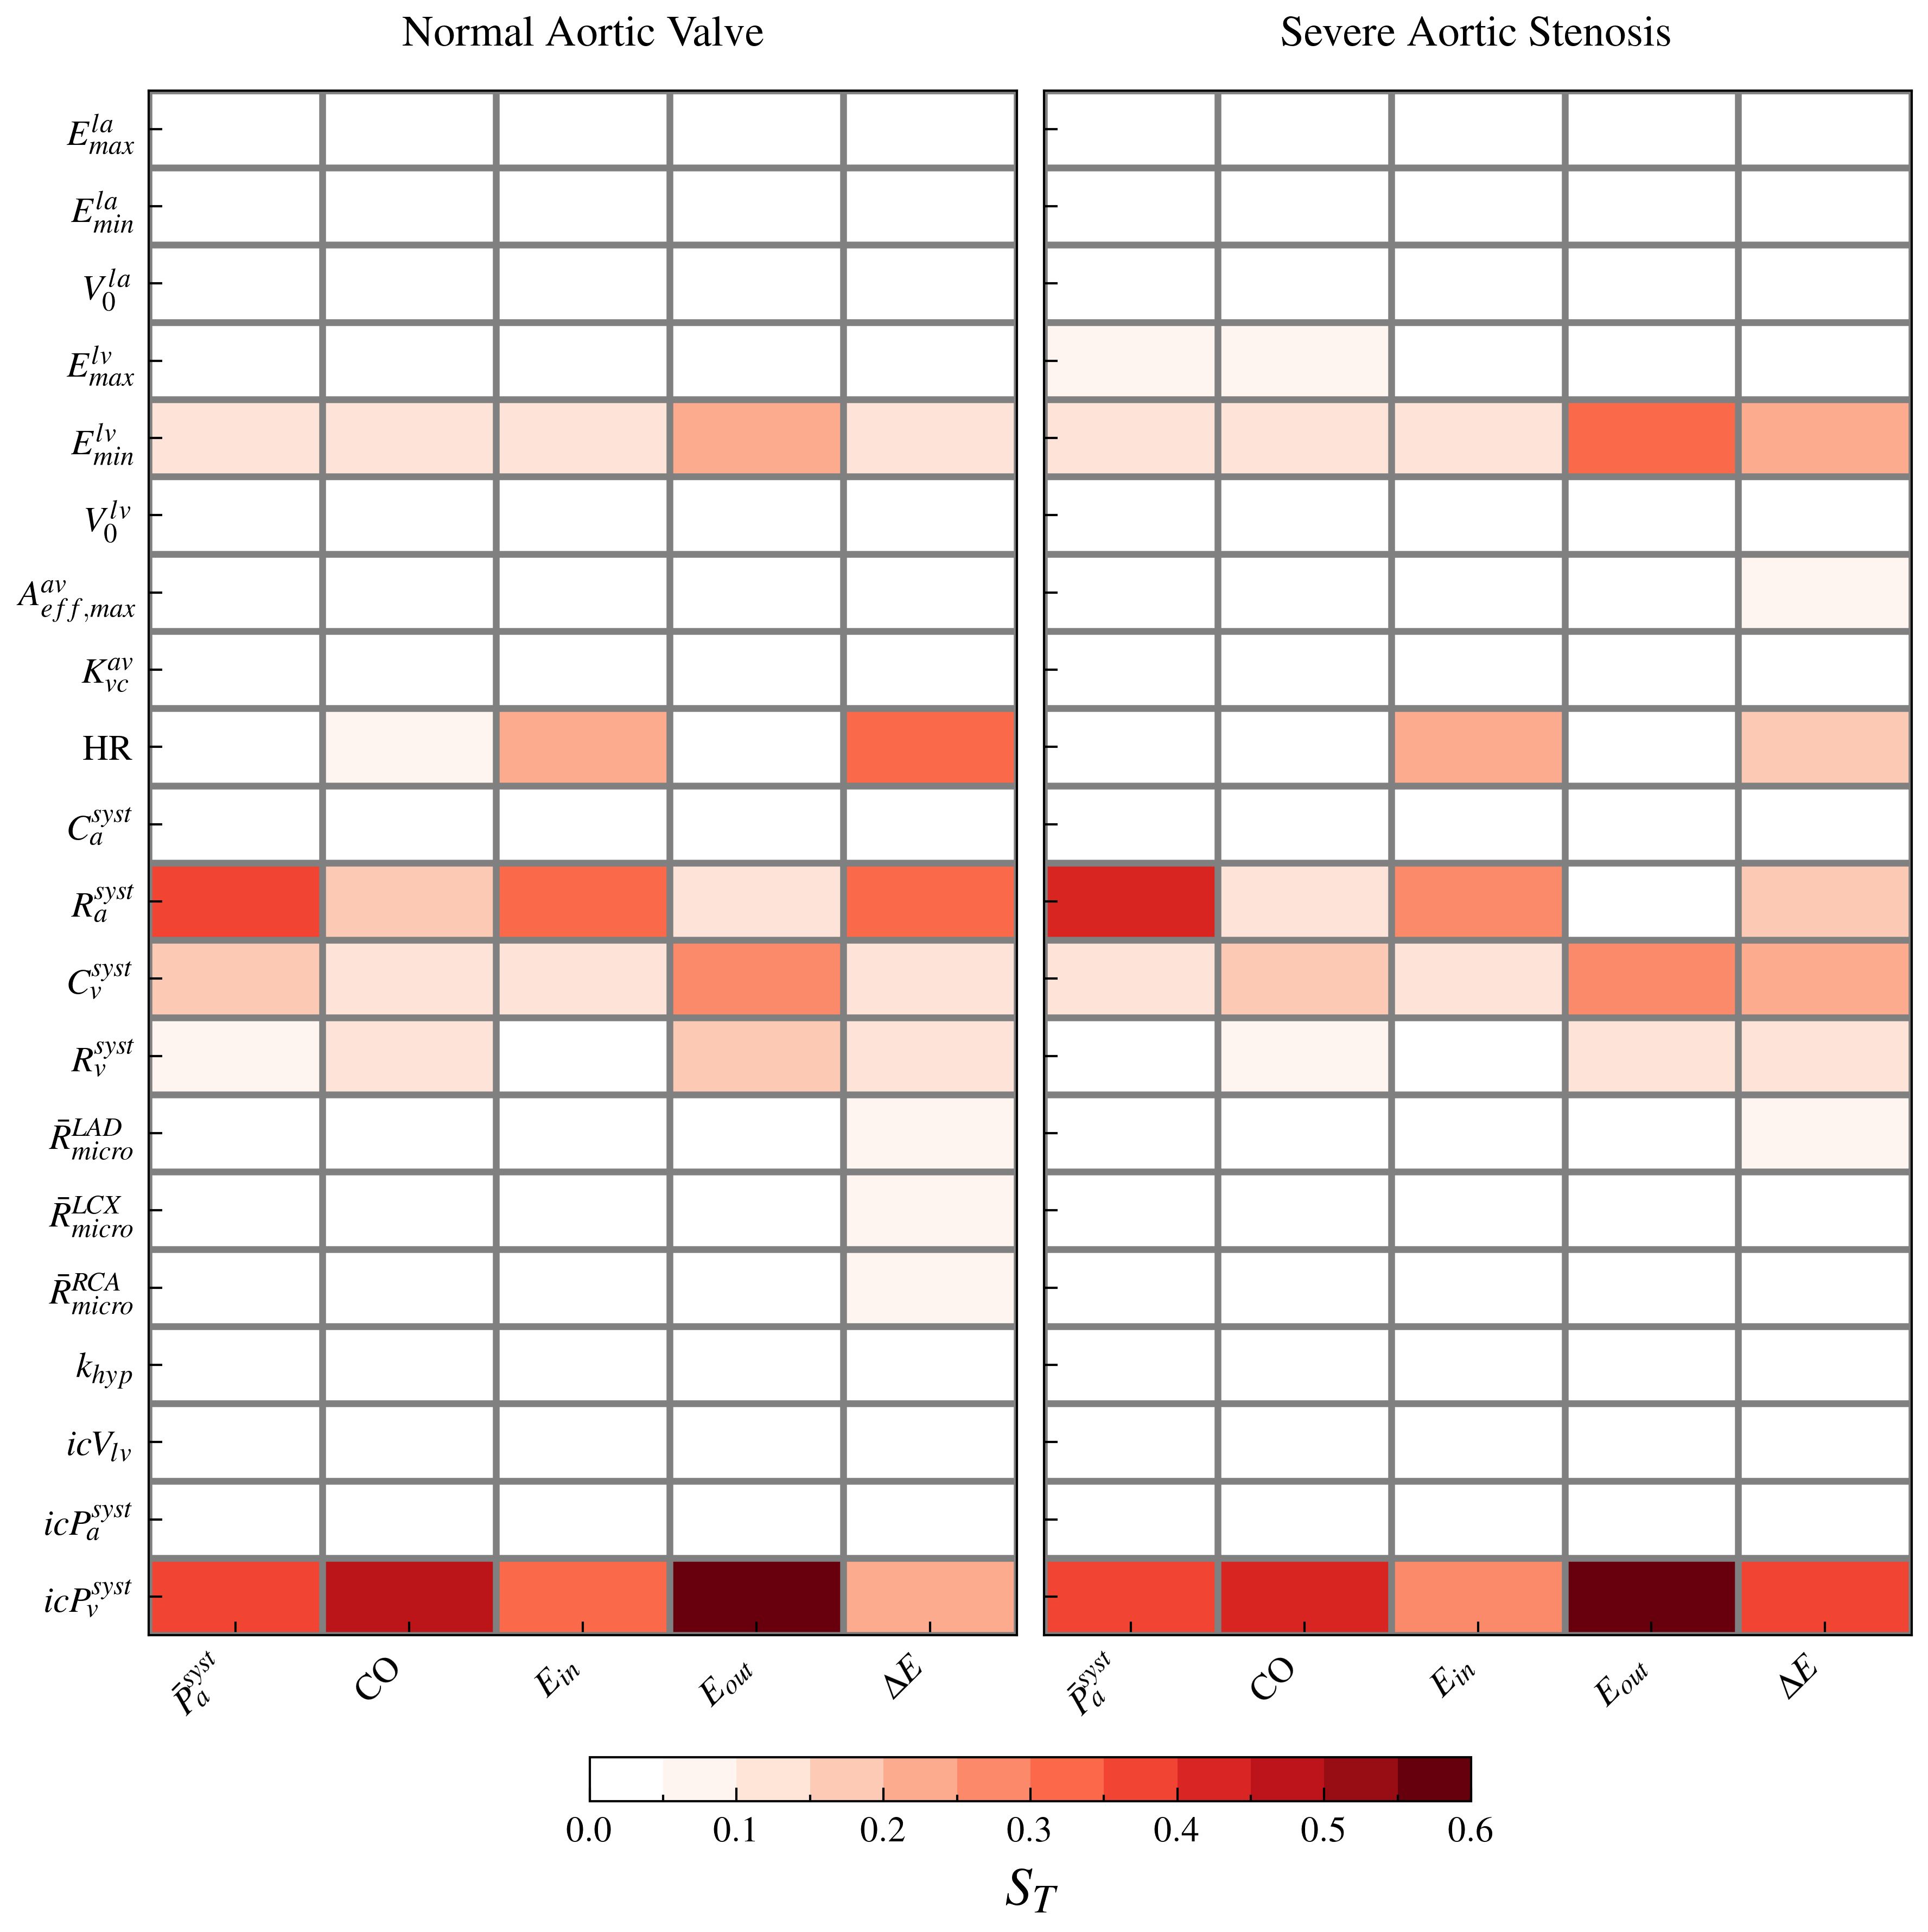

In [8]:
# ST
names = ['Emax_la', 'Emin_la', 'V0la', 'Emax_lv', 'Emin_lv', 'V0lv', 'Amax_av', 'Kvc_av', 'HR', 'Ca_syst', 'Ra_syst', 'Cv_syst', 'Rv_syst', 'Rmicro_max_LAD', 'Rmicro_max_LCX', 'Rmicro_max_RCA', 'hypertrophy_factor', 'icVlv', 'icPa_syst', 'icPv_syst']
names_plot = [r'$E_{max}^{la}$', r'$E_{min}^{la}$', r'$V_{0}^{la}$', r'$E_{max}^{lv}$', r'$E_{min}^{lv}$', r'$V_{0}^{lv}$', r'$A_{eff,max}^{av}$', r'$K_{vc}^{av}$', r'HR', r'$C_{a}^{syst}$', r'$R_{a}^{syst}$', r'$C_{v}^{syst}$', r'$R_{v}^{syst}$', r'$\bar{R}_{micro}^{LAD}$', r'$\bar{R}_{micro}^{LCX}$', r'$\bar{R}_{micro}^{RCA}$', r'$k_{hyp}$', r'$icV_{lv}$', r'$icP_{a}^{syst}$', r'$icP_{v}^{syst}$']
targets = ['Pa_syst_mean', 'CO_lv', 'Ein', 'VO2_total', 'DeltaE']
targets_plot = [r'$\bar{P}_{a}^{syst}$', 'CO', r'$E_{in}$', r'$E_{out}$', r'$\Delta E$']
Stotal_df_all_noAS = pd.read_csv("/Users/martindvoulety/Desktop/Vysoká škola/VUT/Bakalářská práce/model04032026/GSA_data/Sobol_results/Third_Sobol/res/Sobol_S1_ST_All_Targets_noAS.csv")
Stotal_df_all_AS = pd.read_csv("/Users/martindvoulety/Desktop/Vysoká škola/VUT/Bakalářská práce/model04032026/GSA_data/Sobol_results/Third_Sobol/res/Sobol_S1_ST_All_Targets_AS.csv")
Stotal_df_noAS = Stotal_df_all_noAS[["Target_Output", "Parameter", "ST"]]
Stotal_df_AS = Stotal_df_all_AS[["Target_Output", "Parameter", "ST"]]
y_noAS = np.zeros((len(names), len(targets)))
y_AS = np.zeros((len(names), len(targets)))

for inx in range(Stotal_df_noAS.shape[0]):
    target, param, value = Stotal_df_noAS.iloc[inx]
    i = names.index(param)
    j = targets.index(target)
    y_noAS[i,j] = value
    target, param, value = Stotal_df_AS.iloc[inx]
    i = names.index(param)
    j = targets.index(target)
    y_AS[i,j] = value


centimeter = 1/2.54
# colors = ["#ffffff", "#50c2e8", "#040648", "#43f746", "#053b08", "#ee9090", "#de3737", "#630000"]
# boundaries = np.arange(0, 1.05, 0.05)
# cmap = mcolors.ListedColormap(colors)
# cmap = mcolors.LinearSegmentedColormap.from_list("sensitivity", colors)
# norm = mcolors.BoundaryNorm(boundaries, cmap.N)
boundaries = np.arange(0, 0.61, 0.05)
n_bins = len(boundaries) - 1
base_cmap = mpl.cm.Reds
color_list = base_cmap(np.linspace(0, 1, n_bins - 1))
white = np.array([1.0, 1.0, 1.0, 1.0])
new_colors = np.vstack((white, color_list))
cmap = mcolors.ListedColormap(new_colors)
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

#fig, axs = plt.subplots(1, 2, figsize=(20*centimeter, 30*centimeter), layout="constrained")
fig, axs = plt.subplots(1, 2, figsize=(15*centimeter, 15*centimeter), layout="constrained")

im_noAS = axs[0].imshow(y_noAS, cmap=cmap, norm=norm, aspect='auto', interpolation='nearest')
axs[0].set_xticks(np.arange(len(targets)))
axs[0].set_yticks(np.arange(len(names)))
axs[0].set_xticklabels(targets_plot, rotation=45, ha="right")
axs[0].set_yticklabels(names_plot)

axs[0].set_xticks(np.arange(-.5, len(targets), 1), minor=True)
axs[0].set_yticks(np.arange(-.5, len(names), 1), minor=True)
axs[0].grid(which="minor", color="gray", linestyle='-', linewidth=1.5)
axs[0].tick_params(which="minor", bottom=False, left=False)

im_AS = axs[1].imshow(y_AS, cmap=cmap, norm=norm, aspect='auto', interpolation='nearest')
axs[1].set_xticks(np.arange(len(targets)))
axs[1].set_yticks(np.arange(len(names)))
axs[1].set_xticklabels(targets_plot, rotation=45, ha="right")
axs[1].set_yticklabels([])

axs[1].set_xticks(np.arange(-.5, len(targets), 1), minor=True)
axs[1].set_yticks(np.arange(-.5, len(names), 1), minor=True)
axs[1].grid(which="minor", color="gray", linestyle='-', linewidth=1.5)
axs[1].tick_params(which="minor", bottom=False, left=False)

cbar = fig.colorbar(im_noAS, ax=axs, orientation='horizontal', pad=0.02, shrink=0.5)
cbar.set_label(r'$S_T$', fontsize=12)
cbar.set_ticks(np.arange(0,0.61,0.1))

axs[0].set_title("Normal Aortic Valve", fontweight='bold', pad=10)
axs[1].set_title("Severe Aortic Stenosis", fontweight='bold', pad=10)
plt.savefig("Figures/ST.svg")
plt.show()





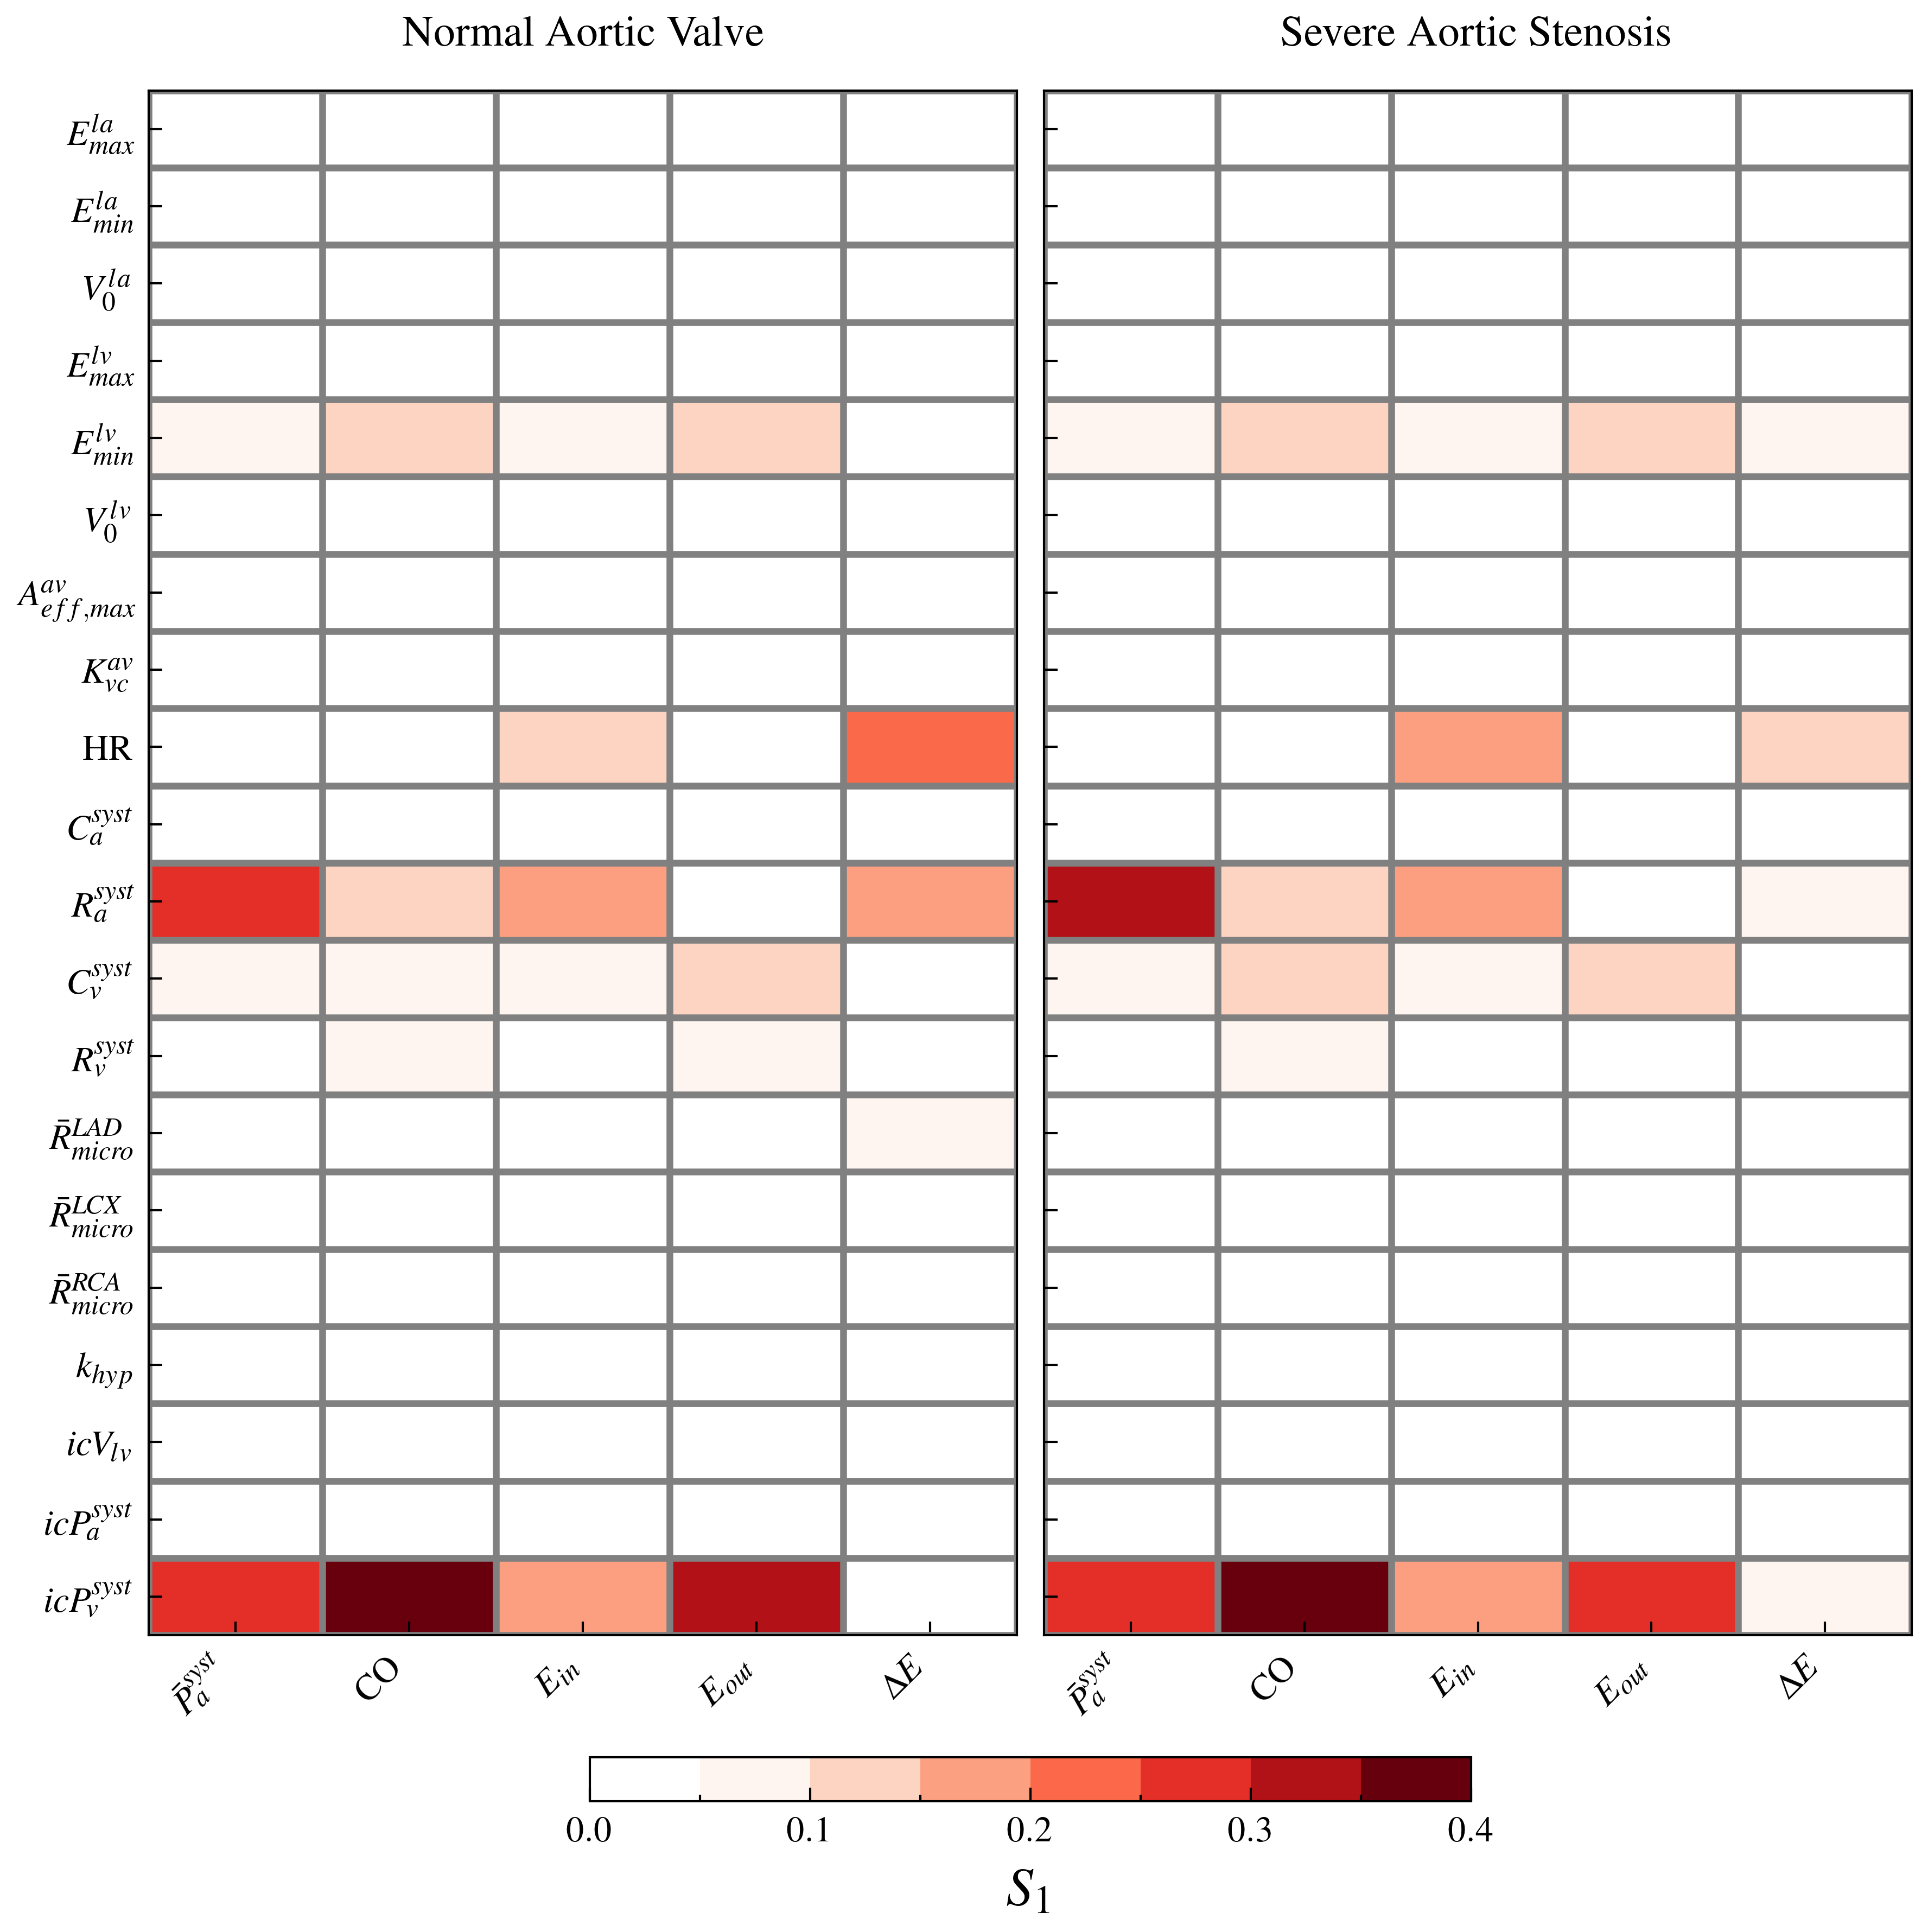

In [ ]:
# S1
names = ['Emax_la', 'Emin_la', 'V0la', 'Emax_lv', 'Emin_lv', 'V0lv', 'Amax_av', 'Kvc_av', 'HR', 'Ca_syst', 'Ra_syst', 'Cv_syst', 'Rv_syst', 'Rmicro_max_LAD', 'Rmicro_max_LCX', 'Rmicro_max_RCA', 'hypertrophy_factor', 'icVlv', 'icPa_syst', 'icPv_syst']
names_plot = [r'$E_{max}^{la}$', r'$E_{min}^{la}$', r'$V_{0}^{la}$', r'$E_{max}^{lv}$', r'$E_{min}^{lv}$', r'$V_{0}^{lv}$', r'$A_{eff,max}^{av}$', r'$K_{vc}^{av}$', r'HR', r'$C_{a}^{syst}$', r'$R_{a}^{syst}$', r'$C_{v}^{syst}$', r'$R_{v}^{syst}$', r'$\bar{R}_{micro}^{LAD}$', r'$\bar{R}_{micro}^{LCX}$', r'$\bar{R}_{micro}^{RCA}$', r'$k_{hyp}$', r'$icV_{lv}$', r'$icP_{a}^{syst}$', r'$icP_{v}^{syst}$']
targets = ['Pa_syst_mean', 'CO_lv', 'Ein', 'VO2_total', 'DeltaE']
targets_plot = [r'$\bar{P}_{a}^{syst}$', 'CO', r'$E_{in}$', r'$E_{out}$', r'$\Delta E$']
Stotal_df_all_noAS = pd.read_csv("/Users/martindvoulety/Desktop/Vysoká škola/VUT/Bakalářská práce/model04032026/GSA_data/Sobol_results/Third_Sobol/res/Sobol_S1_ST_All_Targets_noAS.csv")
Stotal_df_all_AS = pd.read_csv("/Users/martindvoulety/Desktop/Vysoká škola/VUT/Bakalářská práce/model04032026/GSA_data/Sobol_results/Third_Sobol/res/Sobol_S1_ST_All_Targets_AS.csv")
Stotal_df_noAS = Stotal_df_all_noAS[["Target_Output", "Parameter", "S1"]]
Stotal_df_AS = Stotal_df_all_AS[["Target_Output", "Parameter", "S1"]]
y_noAS = np.zeros((len(names), len(targets)))
y_AS = np.zeros((len(names), len(targets)))

for inx in range(Stotal_df_noAS.shape[0]):
    target, param, value = Stotal_df_noAS.iloc[inx]
    i = names.index(param)
    j = targets.index(target)
    y_noAS[i,j] = value
    target, param, value = Stotal_df_AS.iloc[inx]
    i = names.index(param)
    j = targets.index(target)
    y_AS[i,j] = value


centimeter = 1/2.54
# colors = ["#ffffff", "#50c2e8", "#040648", "#43f746", "#053b08", "#ee9090", "#de3737", "#630000"]
# colors = ["#ffffff", "#4b65c3", "#00d22d", "#f10505"]
# color = ["white", "blue", "green", "red"]
# boundaries = np.arange(0, 1.05, 0.05)
# cmap = mcolors.ListedColormap(colors)
# cmap = mcolors.LinearSegmentedColormap.from_list("sensitivity", colors)
# norm = mcolors.BoundaryNorm(boundaries, cmap.N)
boundaries = np.arange(0, 0.41, 0.05)
n_bins = len(boundaries) - 1
base_cmap = mpl.cm.Reds
color_list = base_cmap(np.linspace(0, 1, n_bins - 1))
white = np.array([1.0, 1.0, 1.0, 1.0])
new_colors = np.vstack((white, color_list))
cmap = mcolors.ListedColormap(new_colors)
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

#fig, axs = plt.subplots(1, 2, figsize=(20*centimeter, 30*centimeter), layout="constrained")
fig, axs = plt.subplots(1, 2, figsize=(15*centimeter, 15*centimeter), layout="constrained")

im_noAS = axs[0].imshow(y_noAS, cmap=cmap, norm=norm, aspect='auto', interpolation='nearest')
axs[0].set_xticks(np.arange(len(targets)))
axs[0].set_yticks(np.arange(len(names)))
axs[0].set_xticklabels(targets_plot, rotation=45, ha="right")
axs[0].set_yticklabels(names_plot)

axs[0].set_xticks(np.arange(-.5, len(targets), 1), minor=True)
axs[0].set_yticks(np.arange(-.5, len(names), 1), minor=True)
axs[0].grid(which="minor", color="gray", linestyle='-', linewidth=1.5)
axs[0].tick_params(which="minor", bottom=False, left=False)

im_AS = axs[1].imshow(y_AS, cmap=cmap, norm=norm, aspect='auto', interpolation='nearest')
axs[1].set_xticks(np.arange(len(targets)))
axs[1].set_yticks(np.arange(len(names)))
axs[1].set_xticklabels(targets_plot, rotation=45, ha="right")
axs[1].set_yticklabels([])

axs[1].set_xticks(np.arange(-.5, len(targets), 1), minor=True)
axs[1].set_yticks(np.arange(-.5, len(names), 1), minor=True)
axs[1].grid(which="minor", color="gray", linestyle='-', linewidth=1.5)
axs[1].tick_params(which="minor", bottom=False, left=False)

cbar = fig.colorbar(im_noAS, ax=axs, orientation='horizontal', pad=0.02, shrink=0.5)
cbar.set_label(r'$S_1$', fontsize=12)
cbar.set_ticks(np.arange(0,0.41,0.1))

axs[0].set_title("Normal Aortic Valve", fontweight='bold', pad=10)
axs[1].set_title("Severe Aortic Stenosis", fontweight='bold', pad=10)
plt.savefig("Figures/S1.svg")
plt.show()





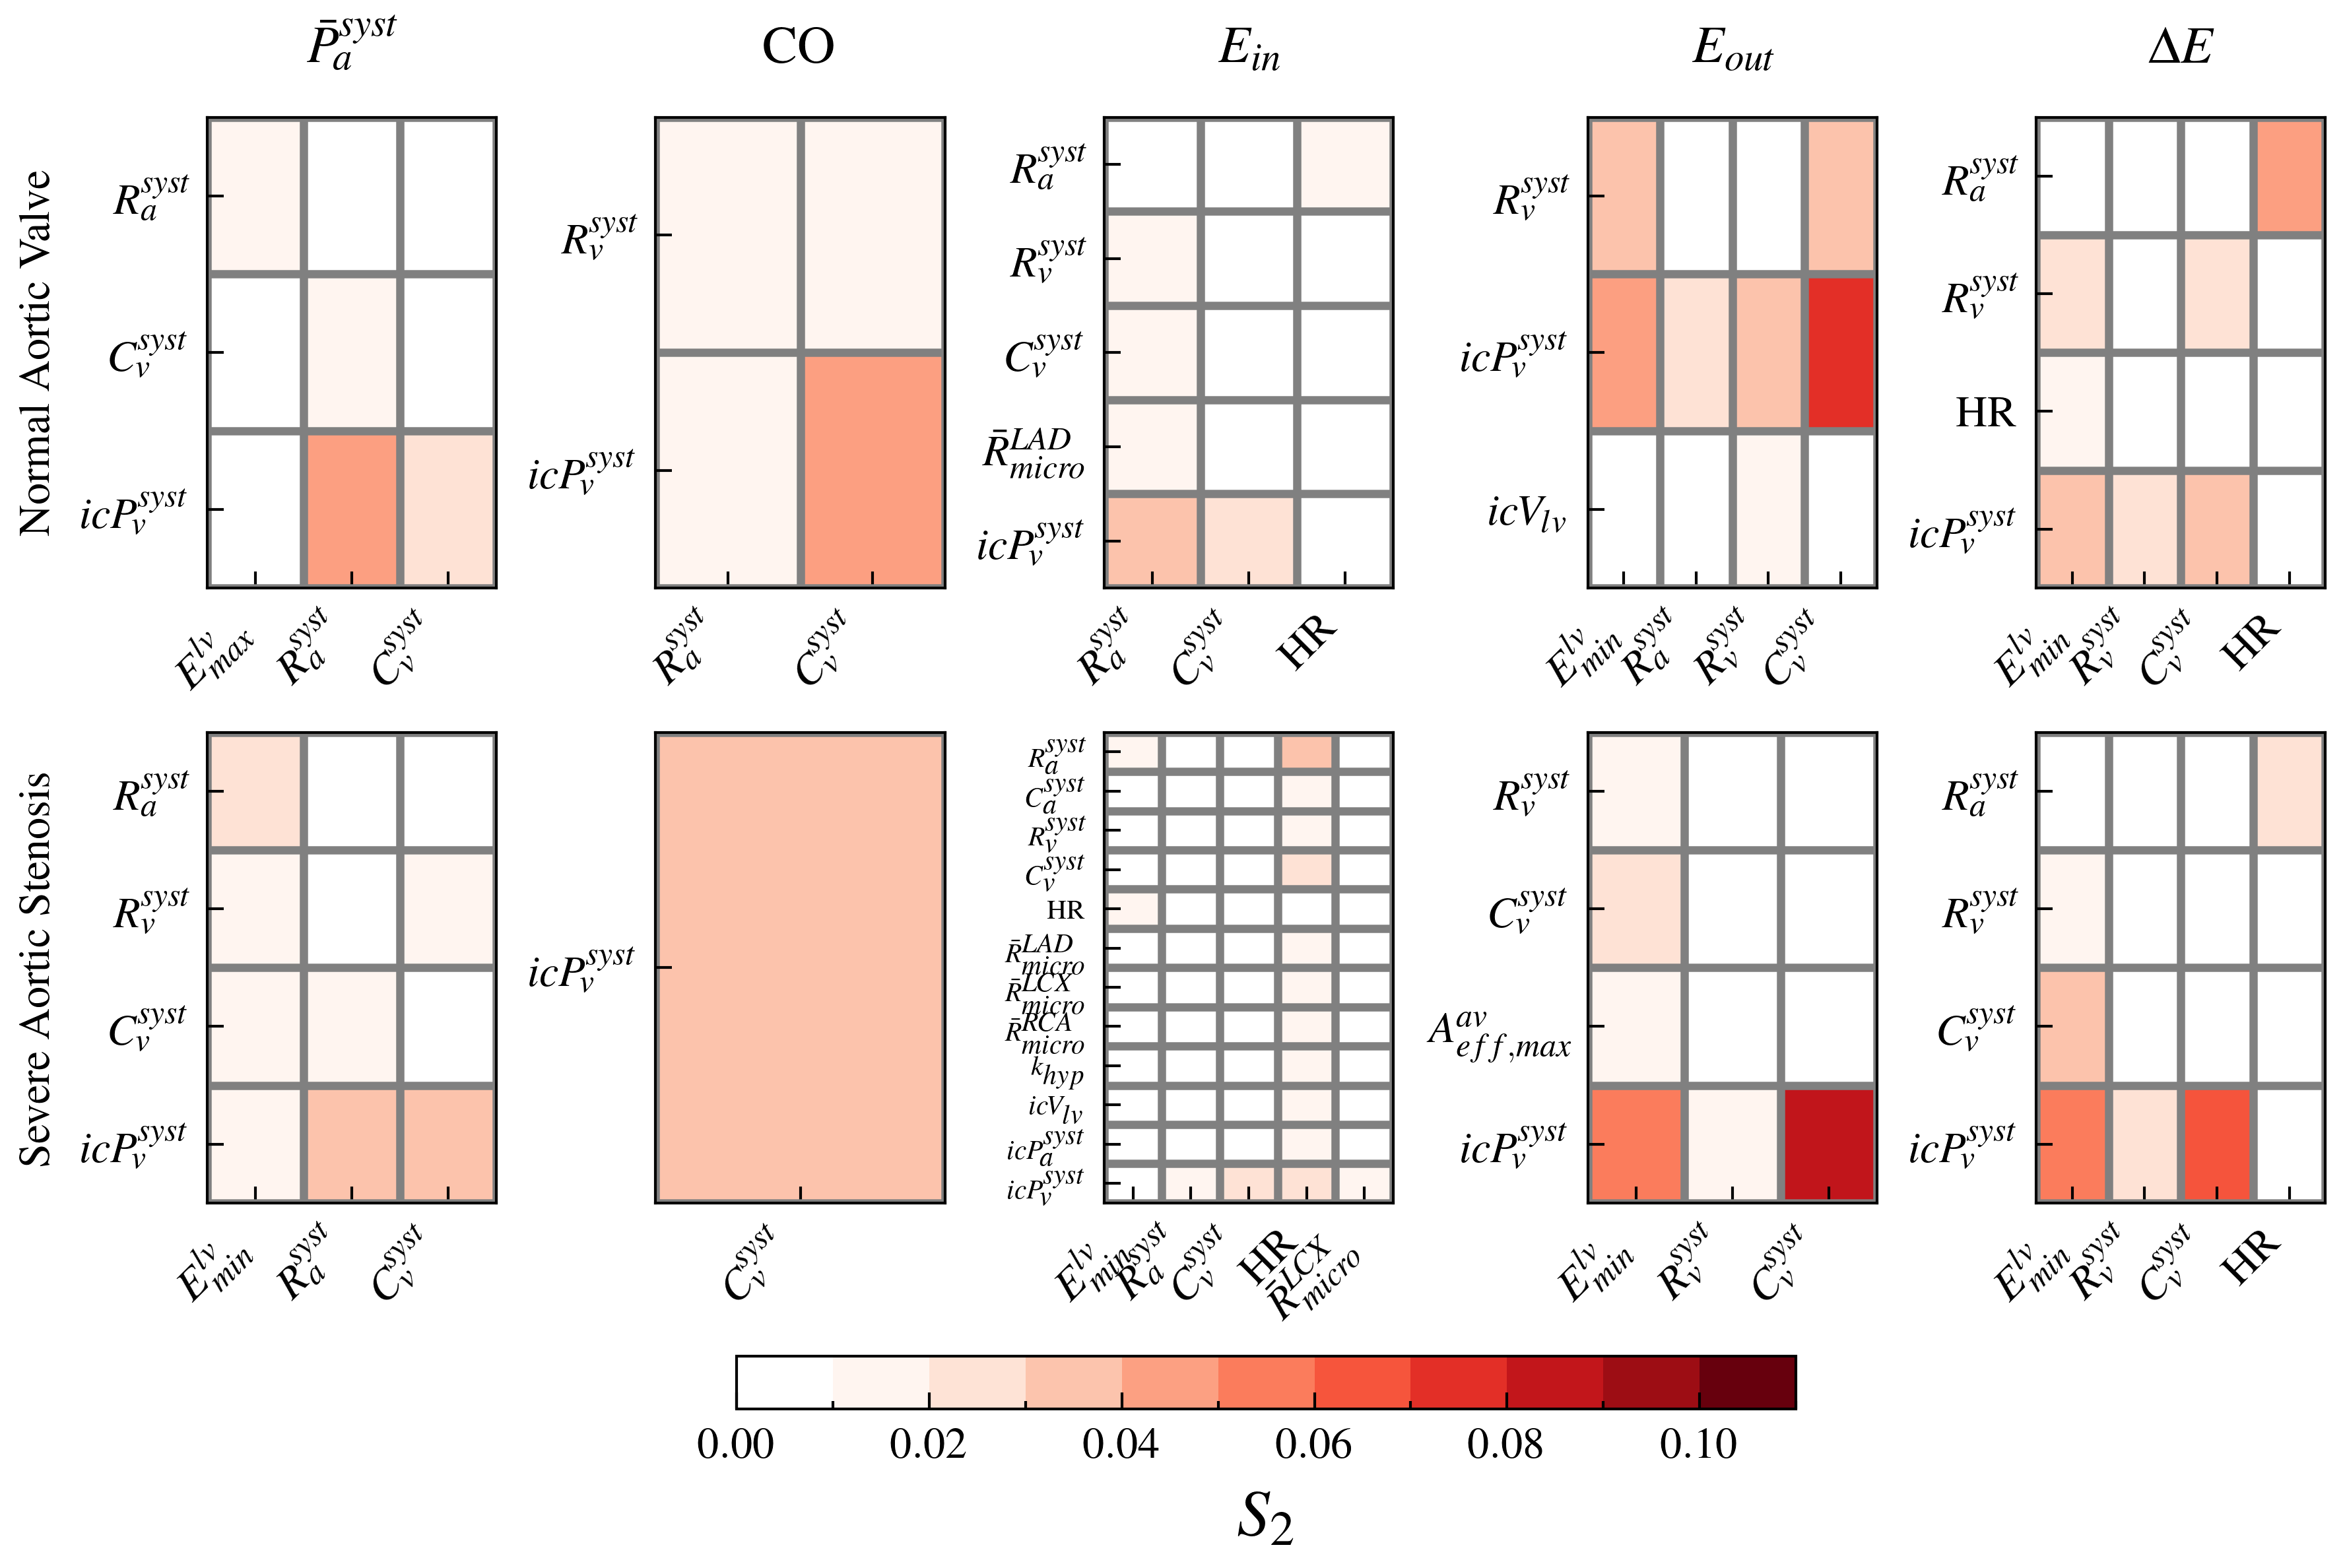

In [10]:
# second order

names = ['Emax_la', 'Emin_la', 'V0la', 'Emax_lv', 'Emin_lv', 'V0lv', 'Amax_av', 'Kvc_av', 'HR', 'Ca_syst', 'Ra_syst', 'Cv_syst', 'Rv_syst', 'Rmicro_max_LAD', 'Rmicro_max_LCX', 'Rmicro_max_RCA', 'hypertrophy_factor', 'icVlv', 'icPa_syst', 'icPv_syst']
names_plot = [r'$E_{max}^{la}$', r'$E_{min}^{la}$', r'$V_{0}^{la}$', r'$E_{max}^{lv}$', r'$E_{min}^{lv}$', r'$V_{0}^{lv}$', r'$A_{eff,max}^{av}$', r'$K_{vc}^{av}$', r'HR', r'$C_{a}^{syst}$', r'$R_{a}^{syst}$', r'$C_{v}^{syst}$', r'$R_{v}^{syst}$', r'$\bar{R}_{micro}^{LAD}$', r'$\bar{R}_{micro}^{LCX}$', r'$\bar{R}_{micro}^{RCA}$', r'$k_{hyp}$', r'$icV_{lv}$', r'$icP_{a}^{syst}$', r'$icP_{v}^{syst}$']
targets = ['Pa_syst_mean', 'CO_lv', 'Ein', 'VO2_total', 'DeltaE']
targets_plot = [r'$\bar{P}_{a}^{syst}$', 'CO', r'$E_{in}$', r'$E_{out}$', r'$\Delta E$']
S2_df_all_noAS = pd.read_csv("/Users/martindvoulety/Desktop/Vysoká škola/VUT/Bakalářská práce/model04032026/GSA_data/Sobol_results/Third_Sobol/res/Sobol_S2_Interactions_noAS.csv")
S2_df_all_AS = pd.read_csv("/Users/martindvoulety/Desktop/Vysoká škola/VUT/Bakalářská práce/model04032026/GSA_data/Sobol_results/Third_Sobol/res/Sobol_S2_Interactions_AS.csv")
S2_df_noAS = S2_df_all_noAS[["Target_Output", "Param_1", "Param_2", "S2"]]
S2_df_AS = S2_df_all_AS[["Target_Output", "Param_1", "Param_2", "S2"]]


S2_df_noAS[S2_df_noAS["Target_Output"] == "DeltaE"]["Param_2"].tolist()

# no AS
# Pa_syst_mean
ax00_names_xlabel = ['Emax_lv', 'Ra_syst', 'Cv_syst']
ax00_names_xlabel_plot = [r'$E_{max}^{lv}$', r'$R_{a}^{syst}$', r'$C_{v}^{syst}$']
ax00_names_ylabel = ['Ra_syst', 'Cv_syst', 'icPv_syst']
ax00_names_ylabel_plot = [r'$R_{a}^{syst}$', r'$C_{v}^{syst}$', r'$icP_{v}^{syst}$']
# CO
ax01_names_xlabel = ['Ra_syst', 'Cv_syst']
ax01_names_xlabel_plot = [r'$R_{a}^{syst}$', r'$C_{v}^{syst}$']
ax01_names_ylabel = ['Rv_syst', 'icPv_syst']
ax01_names_ylabel_plot = [r'$R_{v}^{syst}$', r'$icP_{v}^{syst}$']
#Ein
ax02_names_xlabel = ['Ra_syst', 'Cv_syst', 'HR']
ax02_names_xlabel_plot = [r'$R_{a}^{syst}$', r'$C_{v}^{syst}$', r'HR']
ax02_names_ylabel = ['Ra_syst', 'Rv_syst', 'Cv_syst', 'Rmicro_max_LAD', 'icPv_syst']
ax02_names_ylabel_plot = [r'$R_{a}^{syst}$', r'$R_{v}^{syst}$', r'$C_{v}^{syst}$', r'$\bar{R}_{micro}^{LAD}$', r'$icP_{v}^{syst}$']
#VO2
ax03_names_xlabel = ['Emin_lv', 'Ra_syst', 'Rv_syst', 'Cv_syst']
ax03_names_xlabel_plot = [r'$E_{min}^{lv}$', r'$R_{a}^{syst}$', r'$R_{v}^{syst}$', r'$C_{v}^{syst}$']
ax03_names_ylabel = ['Rv_syst', 'icPv_syst', 'icVlv']
ax03_names_ylabel_plot = [r'$R_{v}^{syst}$', r'$icP_{v}^{syst}$', r'$icV_{lv}$']
#deltaE
ax04_names_xlabel = ['Emin_lv', 'Rv_syst', 'Cv_syst', 'HR']
ax04_names_xlabel_plot = [r'$E_{min}^{lv}$', r'$R_{v}^{syst}$', r'$C_{v}^{syst}$', r'HR']
ax04_names_ylabel = ['Ra_syst', 'Rv_syst', 'HR', 'icPv_syst']
ax04_names_ylabel_plot = [r'$R_{a}^{syst}$', r'$R_{v}^{syst}$', r'HR', r'$icP_{v}^{syst}$']

# AS
# Pa_syst_mean
ax10_names_xlabel = ['Emin_lv', 'Ra_syst', 'Cv_syst']
ax10_names_xlabel_plot = [r'$E_{min}^{lv}$', r'$R_{a}^{syst}$', r'$C_{v}^{syst}$']
ax10_names_ylabel = ['Ra_syst', 'Rv_syst', 'Cv_syst', 'icPv_syst']
ax10_names_ylabel_plot = [r'$R_{a}^{syst}$', r'$R_{v}^{syst}$', r'$C_{v}^{syst}$', r'$icP_{v}^{syst}$']
# CO
ax11_names_xlabel = ['Cv_syst']
ax11_names_xlabel_plot = [r'$C_{v}^{syst}$']
ax11_names_ylabel = ['icPv_syst']
ax11_names_ylabel_plot = [r'$icP_{v}^{syst}$']
#Ein
ax12_names_xlabel = ['Emin_lv', 'Ra_syst', 'Cv_syst', 'HR', 'Rmicro_max_LCX']
ax12_names_xlabel_plot = [r'$E_{min}^{lv}$', r'$R_{a}^{syst}$', r'$C_{v}^{syst}$', r'HR', r'$\bar{R}_{micro}^{LCX}$']
ax12_names_ylabel = ['Ra_syst', 'Ca_syst', 'Rv_syst', 'Cv_syst', 'HR', 'Rmicro_max_LAD', 'Rmicro_max_LCX', 'Rmicro_max_RCA', 'hypertrophy_factor', 'icVlv', 'icPa_syst', 'icPv_syst']
ax12_names_ylabel_plot = [r'$R_{a}^{syst}$', r'$C_{a}^{syst}$', r'$R_{v}^{syst}$', r'$C_{v}^{syst}$', r'HR', r'$\bar{R}_{micro}^{LAD}$', r'$\bar{R}_{micro}^{LCX}$', r'$\bar{R}_{micro}^{RCA}$', r'$k_{hyp}$', r'$icV_{lv}$', r'$icP_{a}^{syst}$', r'$icP_{v}^{syst}$']
#VO2
ax13_names_xlabel = ['Emin_lv', 'Rv_syst', 'Cv_syst']
ax13_names_xlabel_plot = [r'$E_{min}^{lv}$', r'$R_{v}^{syst}$', r'$C_{v}^{syst}$']
ax13_names_ylabel = ['Rv_syst', 'Cv_syst', 'Amax_av', 'icPv_syst']
ax13_names_ylabel_plot = [r'$R_{v}^{syst}$', r'$C_{v}^{syst}$', r'$A_{eff,max}^{av}$', r'$icP_{v}^{syst}$']
#deltaE
ax14_names_xlabel = ['Emin_lv', 'Rv_syst', 'Cv_syst', 'HR']
ax14_names_xlabel_plot = [r'$E_{min}^{lv}$', r'$R_{v}^{syst}$', r'$C_{v}^{syst}$', r'HR']
ax14_names_ylabel = ['Ra_syst', 'Rv_syst', 'Cv_syst', 'icPv_syst']
ax14_names_ylabel_plot = [r'$R_{a}^{syst}$', r'$R_{v}^{syst}$', r'$C_{v}^{syst}$', r'$icP_{v}^{syst}$']


targets = ['Pa_syst_mean', 'CO_lv', 'Ein', 'VO2_total', 'DeltaE']
targets_plot = [r'$\bar{P}_{a}^{syst}$', 'CO', r'$E_{in}$', r'$E_{out}$', r'$\Delta E$']
names_xlabel_noAS = [ax00_names_xlabel, ax01_names_xlabel, ax02_names_xlabel, ax03_names_xlabel, ax04_names_xlabel]
names_xlabel_plot_noAS = [ax00_names_xlabel_plot, ax01_names_xlabel_plot, ax02_names_xlabel_plot, ax03_names_xlabel_plot, ax04_names_xlabel_plot]
names_ylabel_noAS = [ax00_names_ylabel, ax01_names_ylabel, ax02_names_ylabel, ax03_names_ylabel, ax04_names_ylabel]
names_ylabel_plot_noAS = [ax00_names_ylabel_plot, ax01_names_ylabel_plot, ax02_names_ylabel_plot, ax03_names_ylabel_plot, ax04_names_ylabel_plot]

names_xlabel_AS = [ax10_names_xlabel, ax11_names_xlabel, ax12_names_xlabel, ax13_names_xlabel, ax14_names_xlabel]
names_xlabel_plot_AS = [ax10_names_xlabel_plot, ax11_names_xlabel_plot, ax12_names_xlabel_plot, ax13_names_xlabel_plot, ax14_names_xlabel_plot]
names_ylabel_AS = [ax10_names_ylabel, ax11_names_ylabel, ax12_names_ylabel, ax13_names_ylabel, ax14_names_ylabel]
names_ylabel_plot_AS = [ax10_names_ylabel_plot, ax11_names_ylabel_plot, ax12_names_ylabel_plot, ax13_names_ylabel_plot, ax14_names_ylabel_plot]

boundaries = np.arange(0, 0.12, 0.01)
n_bins = len(boundaries) - 1
base_cmap = mpl.cm.Reds
color_list = base_cmap(np.linspace(0, 1, n_bins - 1))
white = np.array([1.0, 1.0, 1.0, 1.0])
new_colors = np.vstack((white, color_list))
cmap = mcolors.ListedColormap(new_colors)
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

fig, axs = plt.subplots(2, 5, figsize=(15*centimeter, 10*centimeter), layout="constrained")

for axer, target in enumerate(targets):
    prms1_noAS = S2_df_noAS[S2_df_noAS["Target_Output"] == target]["Param_1"].tolist()
    prms2_noAS = S2_df_noAS[S2_df_noAS["Target_Output"] == target]["Param_2"].tolist()

    y_noAS = np.zeros((len(set(prms2_noAS)), len(set(prms1_noAS))))
    xlbl = names_xlabel_noAS[axer]
    xlbl_plot = names_xlabel_plot_noAS[axer]
    ylbl = names_ylabel_noAS[axer]
    ylbl_plot = names_ylabel_plot_noAS[axer]

    for inx in range(S2_df_noAS[S2_df_noAS["Target_Output"] == target].shape[0]):
        _, pr1, pr2, value = S2_df_noAS[S2_df_noAS["Target_Output"] == target].iloc[inx]
        i = ylbl.index(pr2)
        j = xlbl.index(pr1)
        y_noAS[i,j] = value
    
    if axer == 0:
        im_noAS = axs[0, axer].imshow(y_noAS, cmap=cmap, norm=norm, aspect='auto', interpolation='nearest')
    else:
        axs[0, axer].imshow(y_noAS, cmap=cmap, norm=norm, aspect='auto', interpolation='nearest')
    axs[0, axer].set_xticks(np.arange(len(xlbl)))
    axs[0, axer].set_yticks(np.arange(len(ylbl)))
    axs[0, axer].set_xticklabels(xlbl_plot, rotation=45, ha="right")
    axs[0, axer].set_yticklabels(ylbl_plot)
    axs[0, axer].set_xticks(np.arange(-.5, len(xlbl), 1), minor=True)
    axs[0, axer].set_yticks(np.arange(-.5, len(ylbl), 1), minor=True)
    axs[0, axer].grid(which="minor", color="gray", linestyle='-', linewidth=1.5)
    axs[0, axer].tick_params(which="minor", bottom=False, left=False)
    axs[0, axer].set_title(f"{targets_plot[axer]}", fontweight='bold', pad=10)



    prms1_AS = S2_df_AS[S2_df_AS["Target_Output"] == target]["Param_1"].tolist()
    prms2_AS = S2_df_AS[S2_df_AS["Target_Output"] == target]["Param_2"].tolist()

    y_AS = np.zeros((len(set(prms2_AS)), len(set(prms1_AS))))
    xlbl = names_xlabel_AS[axer]
    xlbl_plot = names_xlabel_plot_AS[axer]
    ylbl = names_ylabel_AS[axer]
    ylbl_plot = names_ylabel_plot_AS[axer]

    for inx in range(S2_df_AS[S2_df_AS["Target_Output"] == target].shape[0]):
        _, pr1, pr2, value = S2_df_AS[S2_df_AS["Target_Output"] == target].iloc[inx]
        i = ylbl.index(pr2)
        j = xlbl.index(pr1)
        y_AS[i,j] = value
    axs[1, axer].imshow(y_AS, cmap=cmap, norm=norm, aspect='auto', interpolation='nearest')
    axs[1, axer].set_xticks(np.arange(len(xlbl)))
    axs[1, axer].set_yticks(np.arange(len(ylbl)))
    axs[1, axer].set_xticklabels(xlbl_plot, rotation=45, ha="right")
    if axer == 2:
        axs[1, axer].set_yticklabels(ylbl_plot, fontsize=5)
    axs[1, axer].set_yticklabels(ylbl_plot)
    axs[1, axer].set_xticks(np.arange(-.5, len(xlbl), 1), minor=True)
    axs[1, axer].set_yticks(np.arange(-.5, len(ylbl), 1), minor=True)
    axs[1, axer].grid(which="minor", color="gray", linestyle='-', linewidth=1.5)
    axs[1, axer].tick_params(which="minor", bottom=False, left=False)

axs[0, 0].set_ylabel("Normal Aortic Valve")
axs[1, 0].set_ylabel("Severe Aortic Stenosis")
cbar = fig.colorbar(im_noAS, ax=axs, orientation='horizontal', pad=0.02, shrink=0.5)
cbar.set_label(r'$S_2$', fontsize=12)
cbar.set_ticks(np.arange(0, 0.12, 0.02))

plt.savefig("Figures/S2.svg")
plt.show()